In [1]:

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA

# Konfiguracja stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df= pd.read_csv('Teen_Mental_Health_Dataset.csv')

# 1. Podział na zmienne objaśniające i zmienną celu
X = df.drop('depression_label', axis=1)
y = df['depression_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Mapowanie list z nazwami kolumn dla preprocesora
numeric_features = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                    'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
categorical_features = ['gender', 'platform_usage', 'social_interaction_level']

# 4. Definicja transformacji (Skalowanie i One-Hot Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("Zbiór danych został pomyślnie przetworzony i podzielony na zbiór treningowy i testowy.")

Zbiór danych został pomyślnie przetworzony i podzielony na zbiór treningowy i testowy.


Uruchomienie Modelu 1: Las Losowy (Random Forest)


RAPORT KLASYFIKACJI: LAS LOSOWY
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.33      0.50         6

    accuracy                           0.98       240
   macro avg       0.99      0.67      0.75       240
weighted avg       0.98      0.98      0.98       240



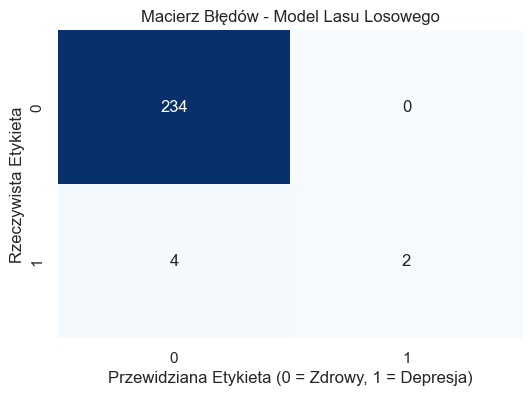

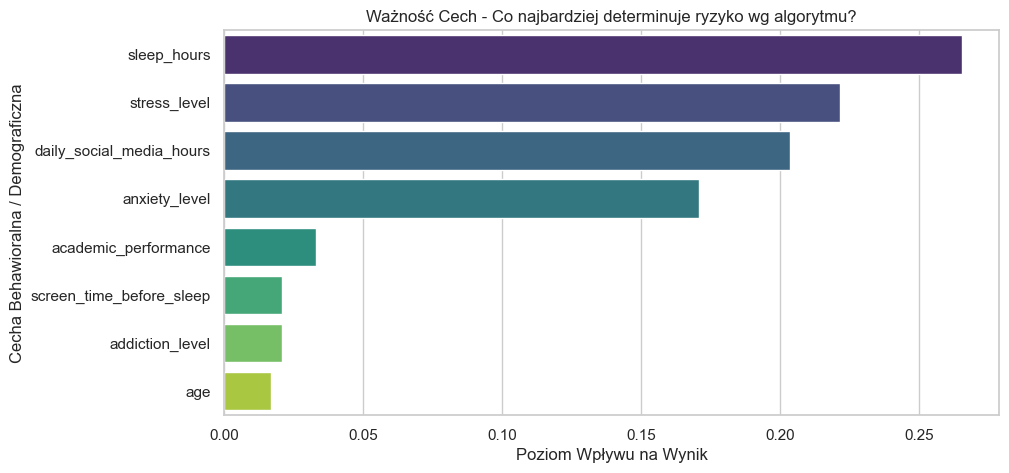

In [2]:
# Inicjalizacja Pipeline dla Lasu Losowego
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight={0: 1, 1: 25}))
])

# Trenowanie i predykcja
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("\n=========================================")
print("RAPORT KLASYFIKACJI: LAS LOSOWY")
print("=========================================")
print(classification_report(y_test, y_pred_rf))

# WIZUALIZACJA 1: Macierz Błędów
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Macierz Błędów - Model Lasu Losowego')
plt.xlabel('Przewidziana Etykieta (0 = Zdrowy, 1 = Depresja)')
plt.ylabel('Rzeczywista Etykieta')
plt.show()

# WIZUALIZACJA 2: Ważność Cech (Feature Importance)
cat_encoder = rf_pipeline.named_steps['preprocessor'].transformers_[1][1]
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

importances = rf_pipeline.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({'Cecha': all_feature_names, 'Waznosc': importances}).sort_values(by='Waznosc', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Waznosc', y='Cecha', data=feat_imp_df.head(8), palette='viridis', hue='Cecha', legend=False)
plt.title('Ważność Cech - Co najbardziej determinuje ryzyko wg algorytmu?')
plt.xlabel('Poziom Wpływu na Wynik')
plt.ylabel('Cecha Behawioralna / Demograficzna')
plt.show()

Uruchomienie Modelu 2: K-Means (Eksperyment Nienadzorowany)


RAPORT KLASYFIKACJI: K-MEANS
              precision    recall  f1-score   support

           0       0.97      0.51      0.67       234
           1       0.02      0.33      0.03         6

    accuracy                           0.50       240
   macro avg       0.49      0.42      0.35       240
weighted avg       0.94      0.50      0.65       240



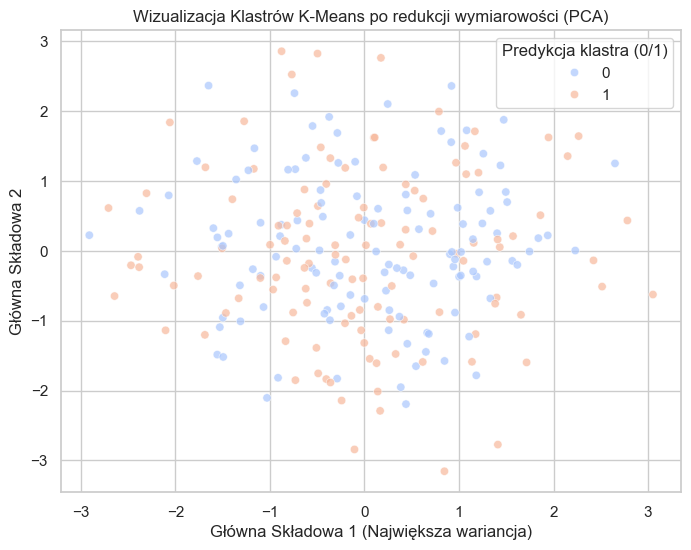

In [3]:
# Inicjalizacja Pipeline dla K-Means (2 klastry)
kmeans_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=2, random_state=42, n_init=10))
])

# Dopasowanie do zbioru treningowego i ewaluacja na testowym
kmeans_pipeline.fit(X_train)
kmeans_pred = kmeans_pipeline.predict(X_test)

# Optymalizacja etykiet: K-Means nadaje klastrom ID w sposób losowy (0 lub 1).
# Sprawdzamy, które ID najlepiej mapuje się na naszą klasę 'depression_label'.
if accuracy_score(y_test, kmeans_pred) < 0.5:
    kmeans_pred = 1 - kmeans_pred

print("\n=========================================")
print("RAPORT KLASYFIKACJI: K-MEANS")
print("=========================================")
print(classification_report(y_test, kmeans_pred))

# WIZUALIZACJA 3: Klastry K-Means rzutowane na przestrzeń 2D za pomocą PCA
X_test_transformed = kmeans_pipeline.named_steps['preprocessor'].transform(X_test)
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_transformed)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=kmeans_pred, palette='coolwarm', alpha=0.7)
plt.title('Wizualizacja Klastrów K-Means po redukcji wymiarowości (PCA)')
plt.xlabel('Główna Składowa 1 (Największa wariancja)')
plt.ylabel('Główna Składowa 2')
plt.legend(title="Predykcja klastra (0/1)")
plt.show()

Bezpośrednie porównanie

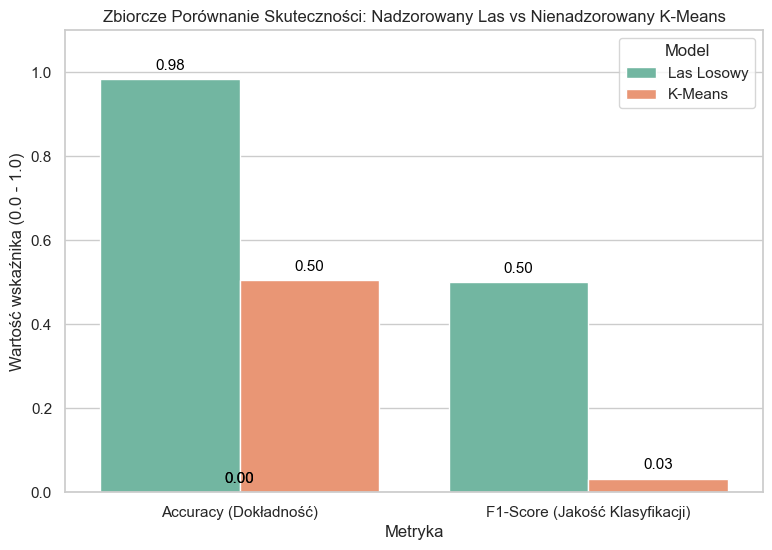

In [4]:
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

acc_km = accuracy_score(y_test, kmeans_pred)
f1_km = f1_score(y_test, kmeans_pred)

metrics_df = pd.DataFrame({
    'Model': ['Las Losowy', 'Las Losowy', 'K-Means', 'K-Means'],
    'Metryka': ['Accuracy (Dokładność)', 'F1-Score (Jakość Klasyfikacji)', 'Accuracy (Dokładność)', 'F1-Score (Jakość Klasyfikacji)'],
    'Wynik': [acc_rf, f1_rf, acc_km, f1_km]
})

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=metrics_df, x='Metryka', y='Wynik', hue='Model', palette='Set2')
plt.title('Zbiorcze Porównanie Skuteczności: Nadzorowany Las vs Nienadzorowany K-Means')
plt.ylim(0, 1.1)
plt.ylabel('Wartość wskaźnika (0.0 - 1.0)')

# Dodanie etykiet tekstowych na słupkach wykresu
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                 textcoords='offset points')
plt.show()

SZKOLENIE I OPTYMALIZACJA MODELI

In [5]:
sns.set_theme(style="whitegrid")

# ==========================================
# 1. WCZYTANIE LOKALNEGO ZBIORU DANYCH
# ==========================================
print("Wczytywanie lokalnego pliku CSV...")
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print(f"Sukces! Liczba załadowanych rekordów: {len(df)}")

# Ujednolicenie nazw kolumn (małe litery, brak spacji), żeby uniknąć głupich błędów
df.columns = df.columns.str.strip().str.lower()

# Odszukanie zmiennej docelowej (depression_label)
target_col = 'depression_label' if 'depression_label' in df.columns else df.columns[-1]

# ==========================================
# 2. PODZIAŁ I PREPROCESSING
# ==========================================
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("Zbiór danych został pomyślnie przetworzony i podzielony na zbiór treningowy i testowy.")

Wczytywanie lokalnego pliku CSV...
Sukces! Liczba załadowanych rekordów: 1200
Zbiór danych został pomyślnie przetworzony i podzielony na zbiór treningowy i testowy.


Strojenie Hiperparametrów

In [6]:
# ==========================================
# 3. STROJENIE HIPERPARAMETRÓW (GridSearchCV)
# ==========================================

# Tworzymy bazowy rurociąg dla Lasu Losowego
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight={0: 1, 1: 25}))
])

# Definiujemy parametry drzew, które GridSearchCV przetestuje i dobierze optymalnie
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

print("Rozpoczynam strojenie parametrów (GridSearchCV) z 5-krotną walidacją krzyżową...")
print("To może zająć kilkanaście sekund...\n")

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Trenowanie z optymalizacją
grid_search.fit(X_train, y_train)

print("\n--- ZAKOŃCZONO OPTYMALIZACJĘ ---")
print("Najlepsze znalezione hiperparametry:")
for param, value in grid_search.best_params_.items():
    print(f" -> {param.replace('classifier__', '')}: {value}")

print(f"\nNajwyższa skuteczność (Accuracy) podczas walidacji treningowej: {grid_search.best_score_:.4f}")

Rozpoczynam strojenie parametrów (GridSearchCV) z 5-krotną walidacją krzyżową...
To może zająć kilkanaście sekund...


--- ZAKOŃCZONO OPTYMALIZACJĘ ---
Najlepsze znalezione hiperparametry:
 -> max_depth: 10
 -> min_samples_split: 10
 -> n_estimators: 50

Najwyższa skuteczność (Accuracy) podczas walidacji treningowej: 0.5200


Ewaluacja Zoptymalizowanego Modelu

RAPORT KLASYFIKACJI
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240



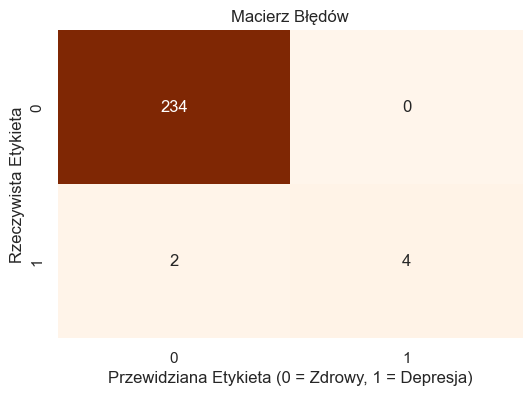

In [7]:
# ==========================================
# 4. EWALUACJA ZOPTYMALIZOWANEGO MODELU (Z MNIEJSZĄ LICZBĄ FALSE NEGATIVES)
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix

# 1. Pobieramy najlepszy model z GridSearchCV
best_rf_model = grid_search.best_estimator_

# 2. Zamiast zwykłych przewidywań, pobieramy surowe prawdopodobieństwa dla klasy 1
# y_scores będzie zawierać wartości od 0.0 do 1.0 dla każdego nastolatka
y_scores = best_rf_model.predict_proba(X_test)[:, 1]

# 3. USTALAMY NOWY, NIŻSZY PRÓG DECYZYJNY (Standardowo jest 0.5)
# Obniżenie progu sprawi, że model będzie bardziej "czujny"
custom_threshold = 0.40
y_pred_custom = (y_scores >= custom_threshold).astype(int)

print("=========================================")
print(f"RAPORT KLASYFIKACJI")
print("=========================================")
print(classification_report(y_test, y_pred_custom, zero_division=0))

#
plt.figure(figsize=(6, 4))
cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title(f'Macierz Błędów')
plt.xlabel('Przewidziana Etykieta (0 = Zdrowy, 1 = Depresja)')
plt.ylabel('Rzeczywista Etykieta')
plt.show()